# House Price Prediction with Linear Regression

**Objective:** Predict median house value based on features such as size (rooms), location (longitude/latitude, proximity to ocean), and household characteristics.

**Dataset:** California Housing dataset (`housing.csv`) — a well-known real-world alternative to the (deprecated) Boston Housing dataset, with numeric + one categorical feature.

**Pipeline:**
1. Load data & explore distributions
2. Handle missing data
3. Preprocess inputs (encode categorical, normalize numeric features)
4. Train/test split
5. Train a Linear Regression model
6. Evaluate with MSE, RMSE, MAE, R²


## 1. Load the Dataset and Explore Data Distributions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('housing.csv')
print("Shape:", df.shape)
df.head()


Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**Column overview:**
- `longitude`, `latitude` — location coordinates
- `housing_median_age` — median age of houses in the block
- `total_rooms`, `total_bedrooms`, `population`, `households` — size/density features
- `median_income` — median income of households (in tens of thousands of $)
- `median_house_value` — **target variable** we want to predict
- `ocean_proximity` — categorical feature describing location relative to the ocean


In [4]:
# Check missing values
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
# Categorical feature distribution
df['ocean_proximity'].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

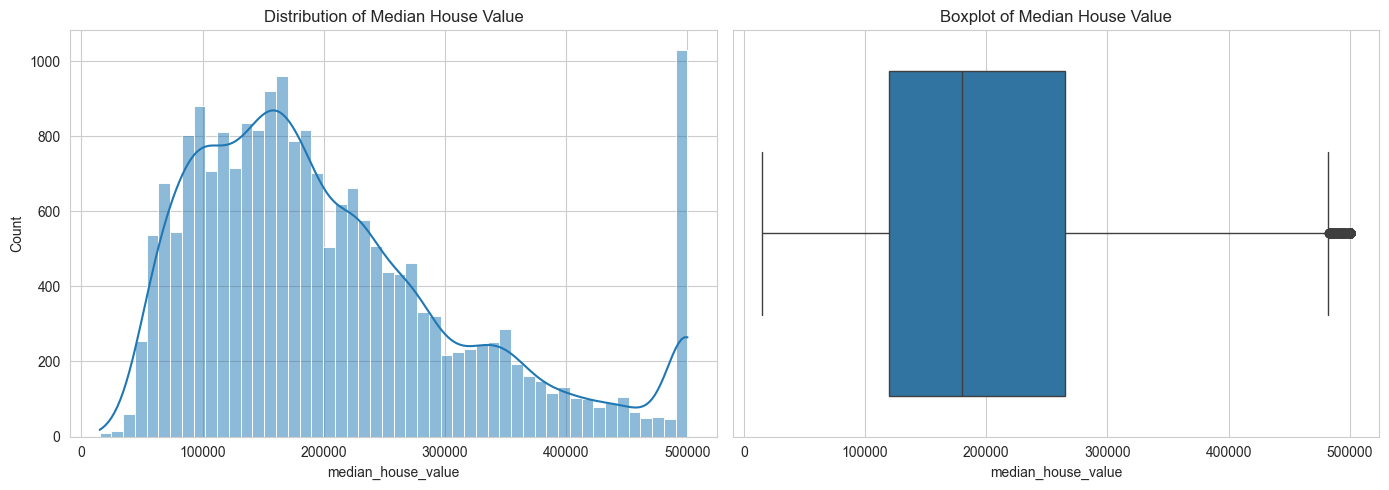

In [6]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Median House Value')
sns.boxplot(x=df['median_house_value'], ax=axes[1])
axes[1].set_title('Boxplot of Median House Value')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100)
plt.show()


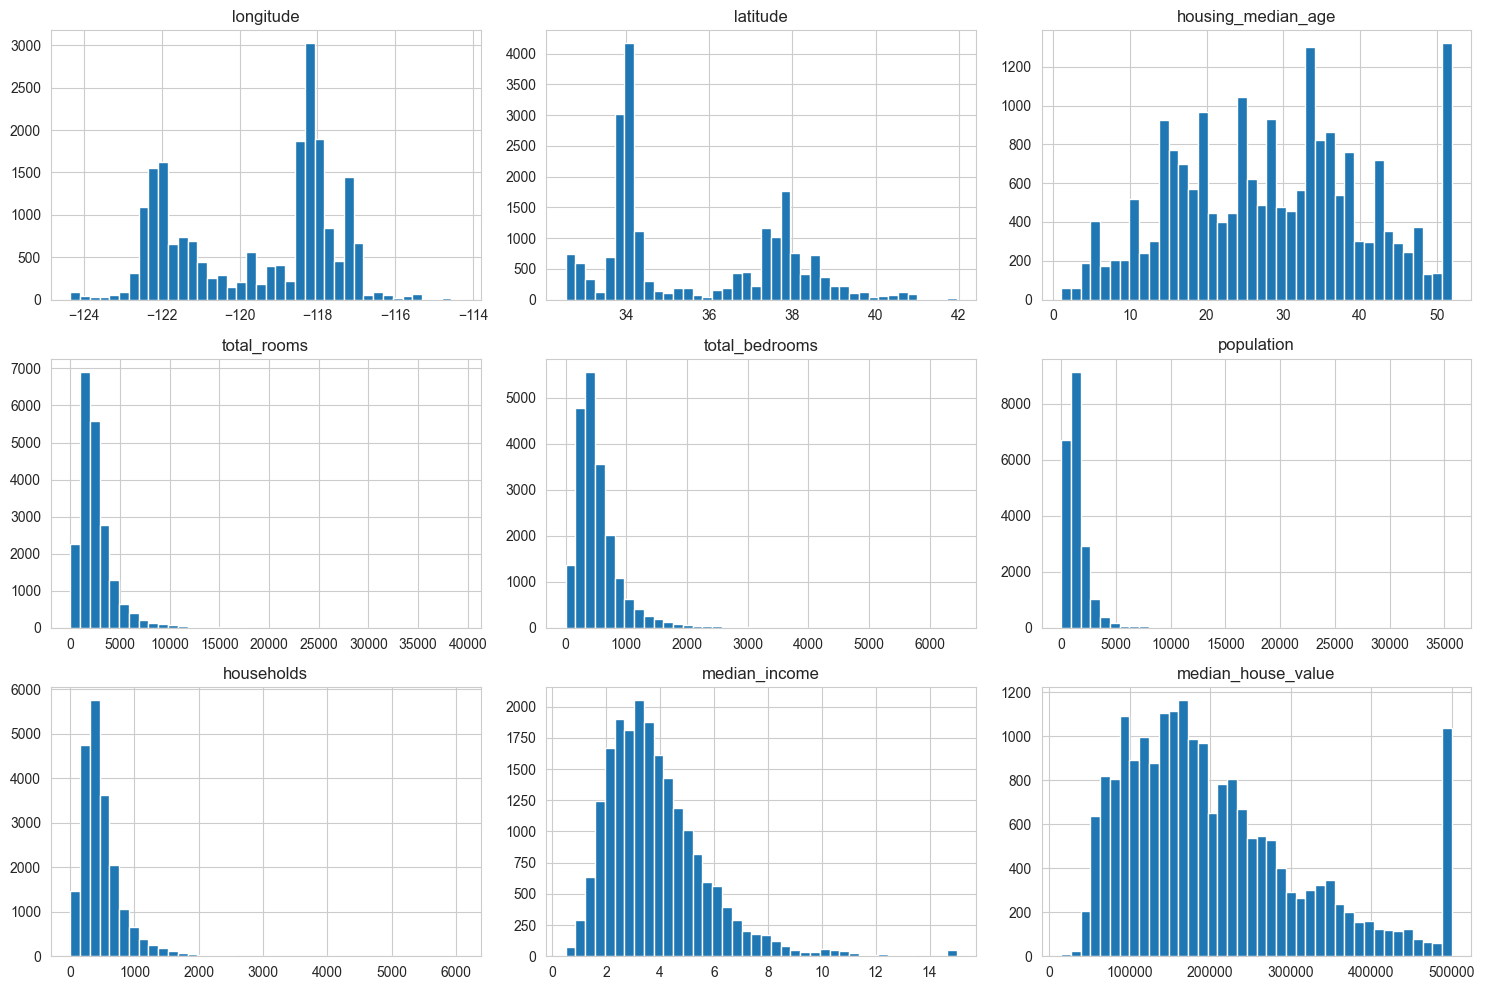

In [7]:
# Distributions of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].hist(bins=40, figsize=(15, 10))
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100)
plt.show()


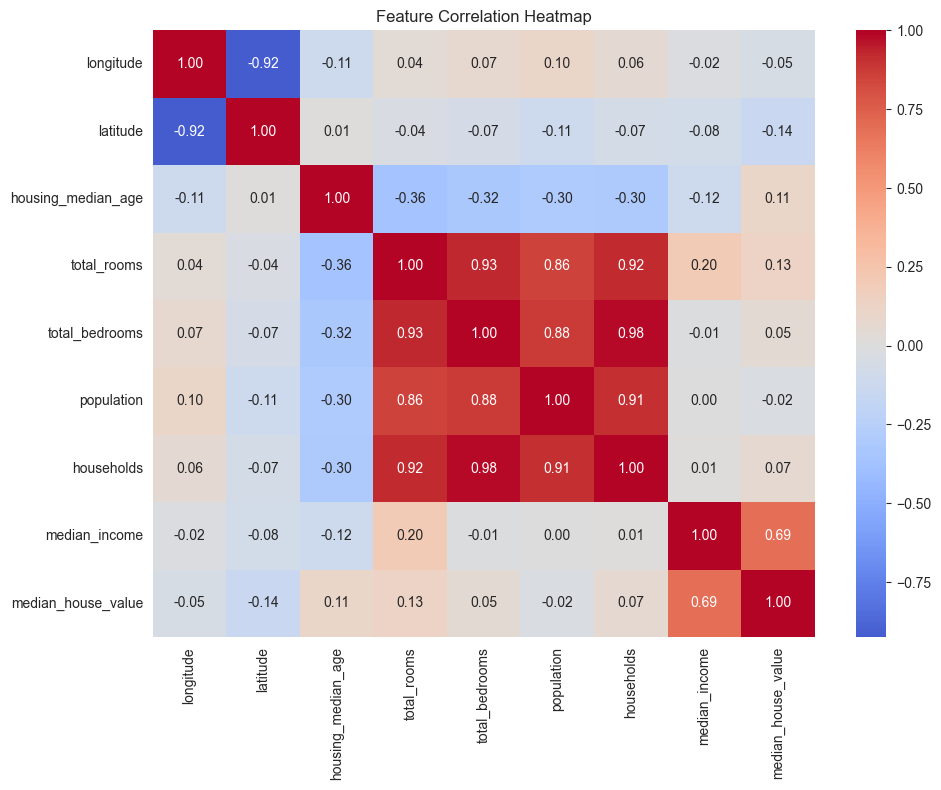

In [8]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()


**Observation:** `median_income` shows the strongest correlation with `median_house_value`, which matches intuition — wealthier areas tend to have pricier houses. `total_rooms`, `total_bedrooms`, `population`, and `households` are all highly correlated with each other (they all scale with neighborhood size).

## 2. Handle Missing Data

In [9]:
# Only 'total_bedrooms' has missing values
missing_count = df['total_bedrooms'].isnull().sum()
print(f"Missing values in 'total_bedrooms': {missing_count} ({missing_count/len(df)*100:.2f}%)")


Missing values in 'total_bedrooms': 207 (1.00%)


In [10]:
# Impute missing values with the median (robust to outliers/skew)
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## 3. Preprocess Inputs

Steps:
- **Feature engineering**: create more informative ratio features (rooms per household, bedrooms per room, population per household) — a common improvement over raw counts.
- **Encode** the categorical `ocean_proximity` column with one-hot encoding.
- **Normalize** numeric features using `StandardScaler` (fit on train, applied to test — to avoid data leakage).


In [11]:
# Feature engineering: ratio features tend to be more predictive than raw counts
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


In [12]:
# One-hot encode the categorical column
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df_encoded.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


In [13]:
# Separate features (X) and target (y)
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

print("Features:", list(X.columns))
print("Target: median_house_value")


Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Target: median_house_value


## 4. Split into Train/Test Sets

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)


Train set: (16512, 15)
Test set: (4128, 15)


In [15]:
from sklearn.preprocessing import StandardScaler

# Fit the scaler ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training features shape:", X_train_scaled.shape)


Scaled training features shape: (16512, 15)


## 5. Train a Regression Model (Linear Regression)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained.")
print("Intercept:", model.intercept_)


Model trained.
Intercept: 207194.6937378879


In [17]:
# Inspect feature importance via coefficients (since features are standardized,
# larger absolute coefficient => stronger influence on price)
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df


,feature,coefficient
7,median_income,78904.439397
1,latitude,-56638.231159
0,longitude,-56276.058852
5,population,-46320.285471
6,households,40233.724848
9,bedrooms_per_room,16809.104551
11,ocean_proximity_INLAND,-16257.039232
2,housing_median_age,14122.304752
8,rooms_per_household,7699.448488
3,total_rooms,5881.104980


## 6. Evaluate Predictions

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE):      {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Error (MAE):     {mae:,.2f}")
print(f"R-squared (R2):                {r2:.4f}")


Mean Squared Error (MSE):      5,280,716,470.09
Root Mean Squared Error (RMSE): 72,668.54
Mean Absolute Error (MAE):     50,888.66
R-squared (R2):                0.5970


**Interpretation:**
- **RMSE** is in the same units as the target ($) — on average, predictions are off by roughly this amount.
- **MAE** is the average absolute error, less sensitive to large outliers than MSE/RMSE.
- **R²** tells us the proportion of variance in house prices explained by the model (closer to 1 is better).


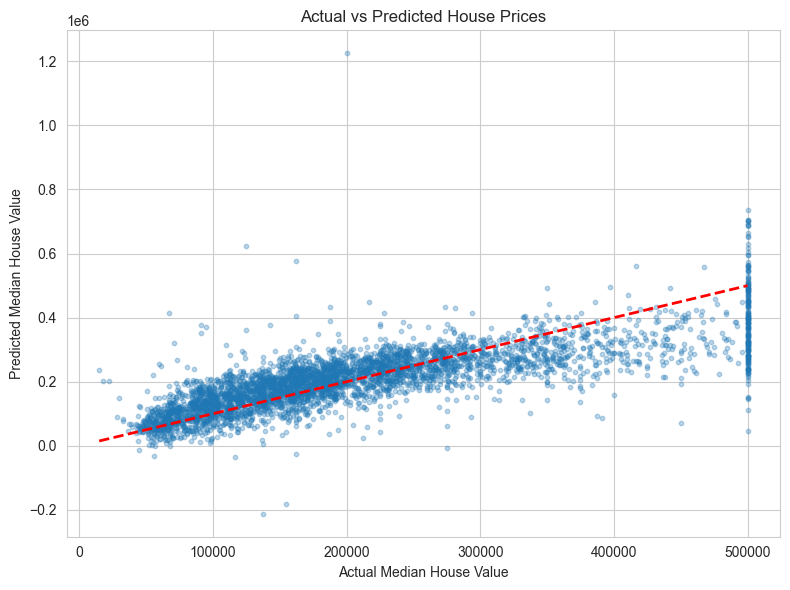

In [19]:
# Visualize predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=100)
plt.show()


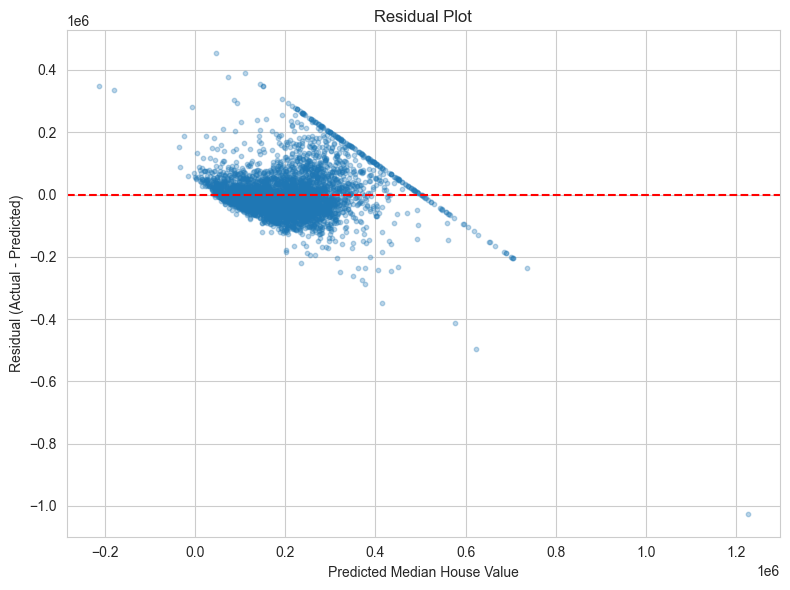

In [20]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=100)
plt.show()


## Summary

- Loaded the California Housing dataset (20,640 rows, 10 columns) and explored feature distributions and correlations.
- Handled the 207 missing values in `total_bedrooms` via median imputation.
- Engineered ratio features and one-hot encoded the categorical `ocean_proximity` column.
- Standardized features and split data 80/20 into train/test sets.
- Trained a Linear Regression model and evaluated it using MSE, RMSE, MAE, and R².
- `median_income` was the strongest positive predictor of house price. Residual plots show the model is reasonably well-behaved but slightly underperforms on very high-value homes (a known limitation of plain linear regression on this dataset — non-linear models like Random Forest or Gradient Boosting typically do better).
